In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

Matplotlib is building the font cache; this may take a moment.


In [2]:
ruta = Path("../data/raw/Base_de_datos.xlsx")

df = pd.read_excel(ruta)

df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [3]:
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

Cantidad de filas: 10763
Cantidad de columnas: 23


In [4]:
df.dtypes

tipo_credito                              int64
fecha_prestamo                   datetime64[us]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                                str
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datacredito           

In [5]:
df.isnull().sum().sort_values(ascending=False)

tendencia_ingresos               2932
promedio_ingresos_datacredito    2930
saldo_mora_codeudor               590
saldo_principal                   405
saldo_mora                        156
saldo_total                       156
puntaje_datacredito                 6
salario_cliente                     0
tipo_laboral                        0
edad_cliente                        0
plazo_meses                         0
capital_prestado                    0
fecha_prestamo                      0
tipo_credito                        0
total_otros_prestamos               0
cant_creditosvigentes               0
huella_consulta                     0
cuota_pactada                       0
puntaje                             0
creditos_sectorCooperativo          0
creditos_sectorFinanciero           0
creditos_sectorReal                 0
Pago_atiempo                        0
dtype: int64

In [6]:
df["Pago_atiempo"].value_counts()

Pago_atiempo
1    10252
0      511
Name: count, dtype: int64

# Distribución de la variable objetivo

En esta sección se analiza la distribución de la variable objetivo Pago_atiempo, la cual representa si el cliente realizó el pago dentro del plazo establecido.

Este análisis permite identificar si existe desbalance de clases, aspecto importante para el entrenamiento y evaluación de modelos de clasificación supervisada.

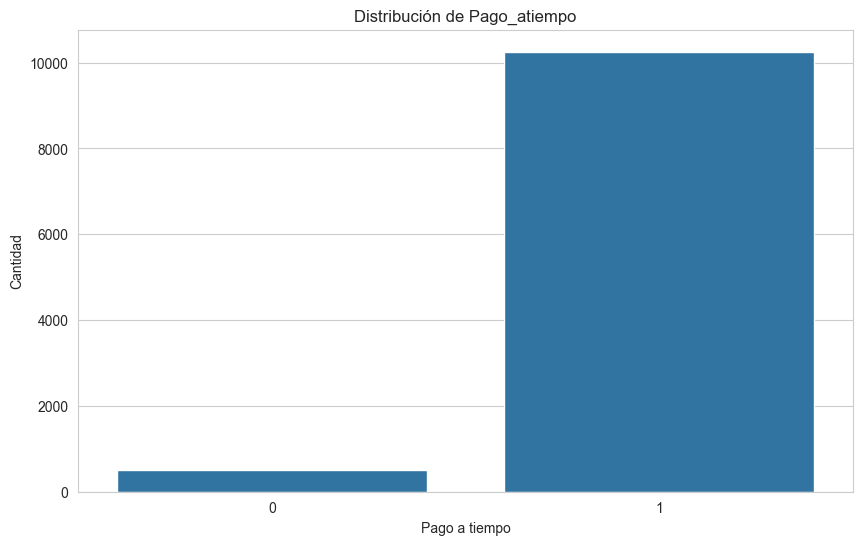

In [7]:
sns.countplot(data=df, x="Pago_atiempo")

plt.title("Distribución de Pago_atiempo")
plt.xlabel("Pago a tiempo")
plt.ylabel("Cantidad")

plt.show()

## Interpretación

Se observa un fuerte desbalance entre las clases de la variable objetivo, donde predominan ampliamente los clientes que realizaron el pago a tiempo.

Este comportamiento puede afectar el rendimiento de algunos modelos de clasificación, por lo que será importante utilizar métricas adecuadas como Recall, F1-Score y ROC-AUC durante la etapa de modelado.

# Análisis univariado de variables numéricas

A continuación se analizan las distribuciones individuales de las variables numéricas del dataset.

Este análisis permite identificar:
- posibles valores atípicos,
- asimetrías,
- concentraciones de datos,
- distribuciones normales o sesgadas,
- y patrones relevantes para la etapa de modelado.

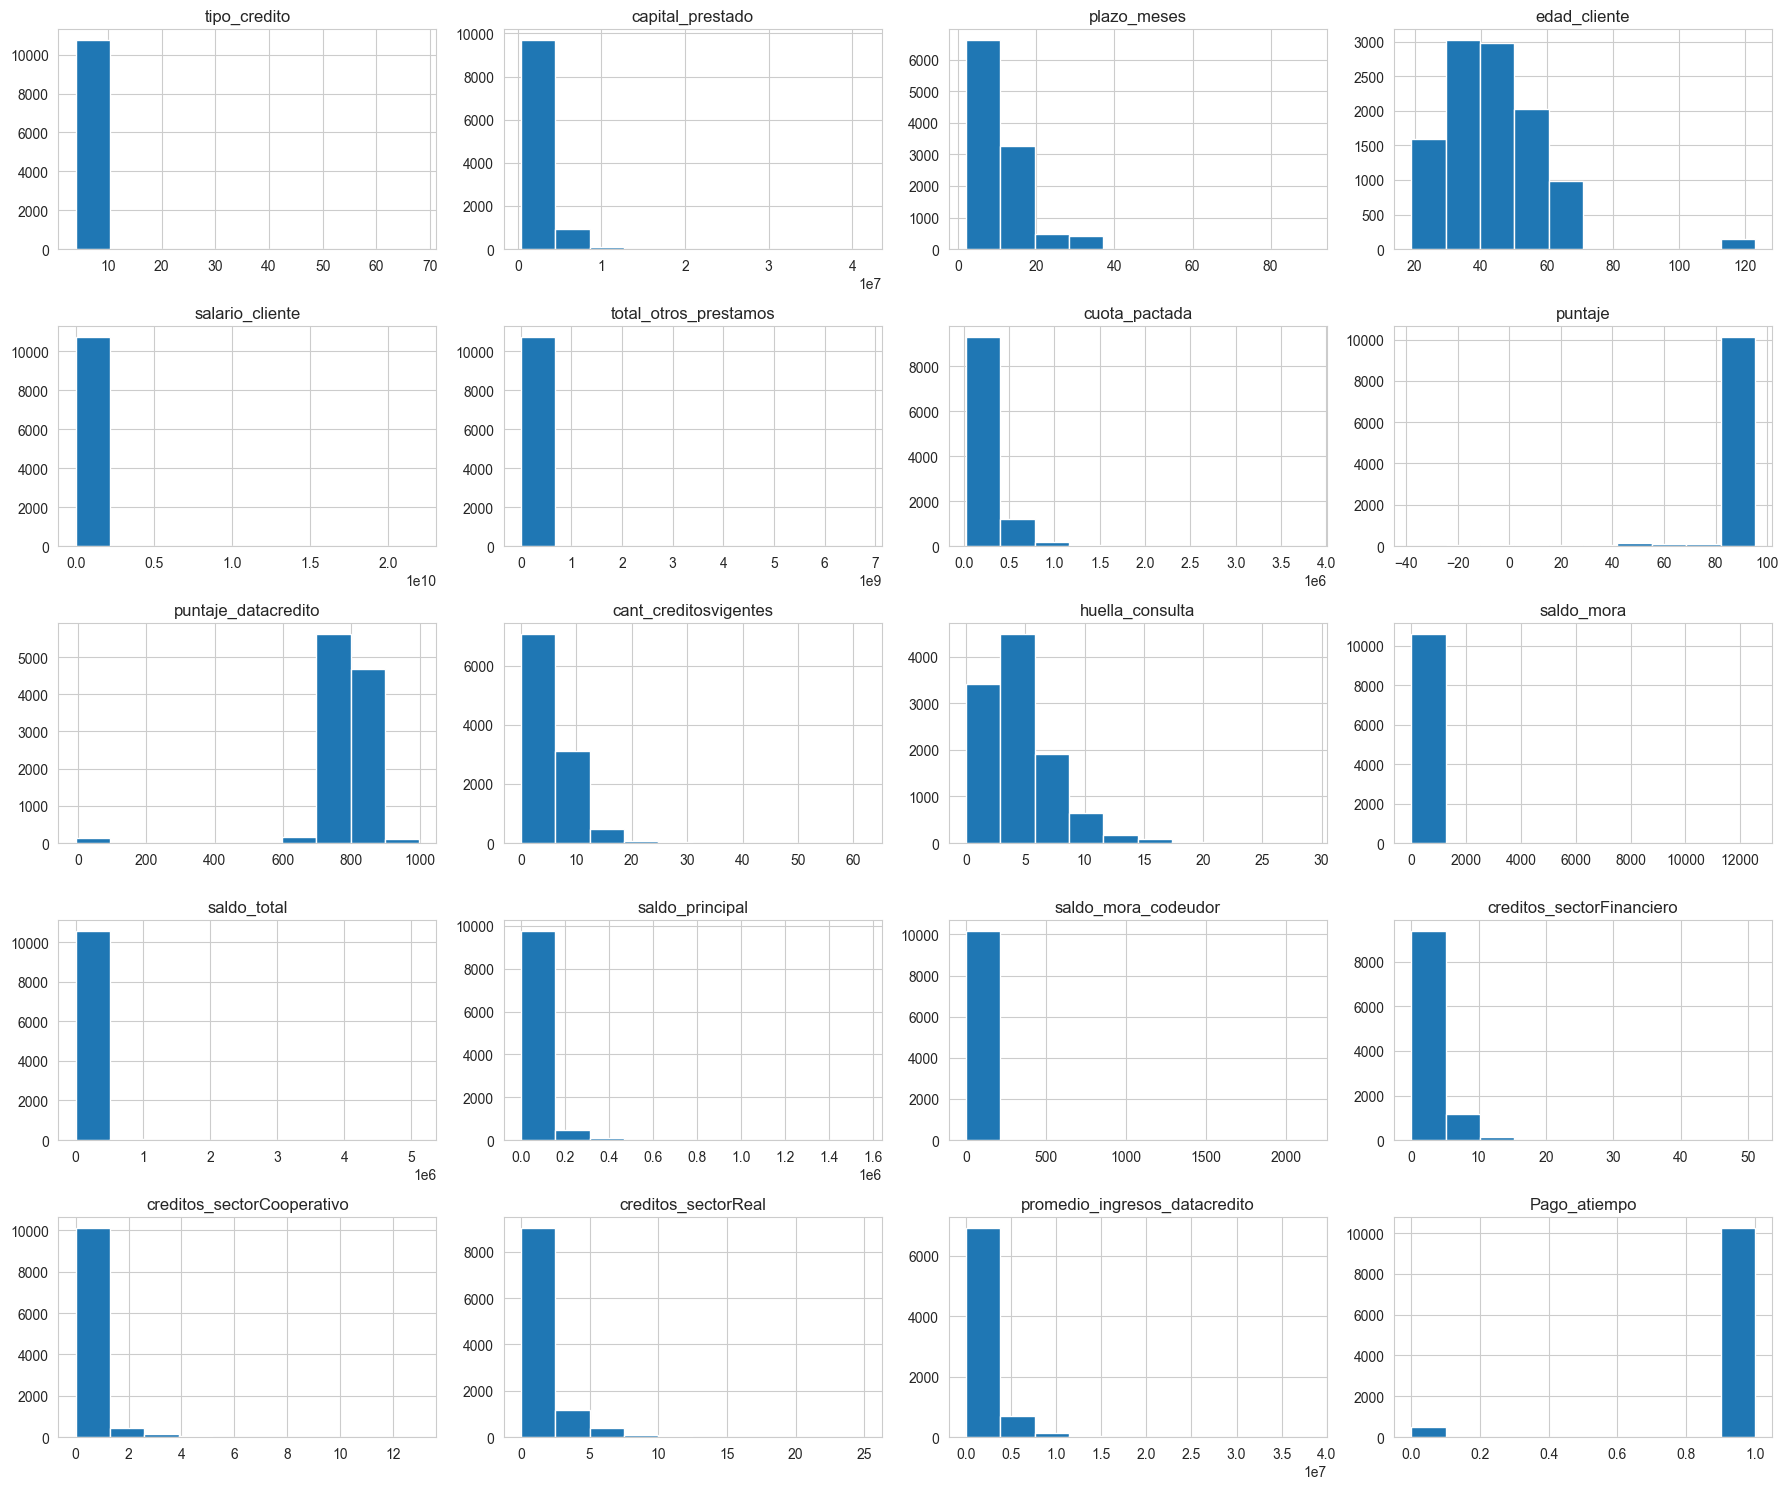

In [9]:
variables_numericas = df.select_dtypes(include=np.number)

variables_numericas.hist(figsize=(18,15))

plt.tight_layout()

plt.show()

## Interpretación

Se observan distintas distribuciones entre las variables numéricas del dataset.

Algunas variables presentan asimetrías importantes y concentraciones en determinados rangos, especialmente en variables relacionadas con saldos, préstamos y cantidades de créditos.

También se identifican posibles valores extremos en variables financieras, aspecto que deberá considerarse durante el preprocesamiento y entrenamiento de modelos.

# Matriz de correlación

La matriz de correlación permite analizar la relación lineal entre las variables numéricas del dataset.

Esto facilita identificar:
- variables altamente relacionadas,
- posibles problemas de multicolinealidad,
- y atributos con mayor relación respecto a la variable objetivo.

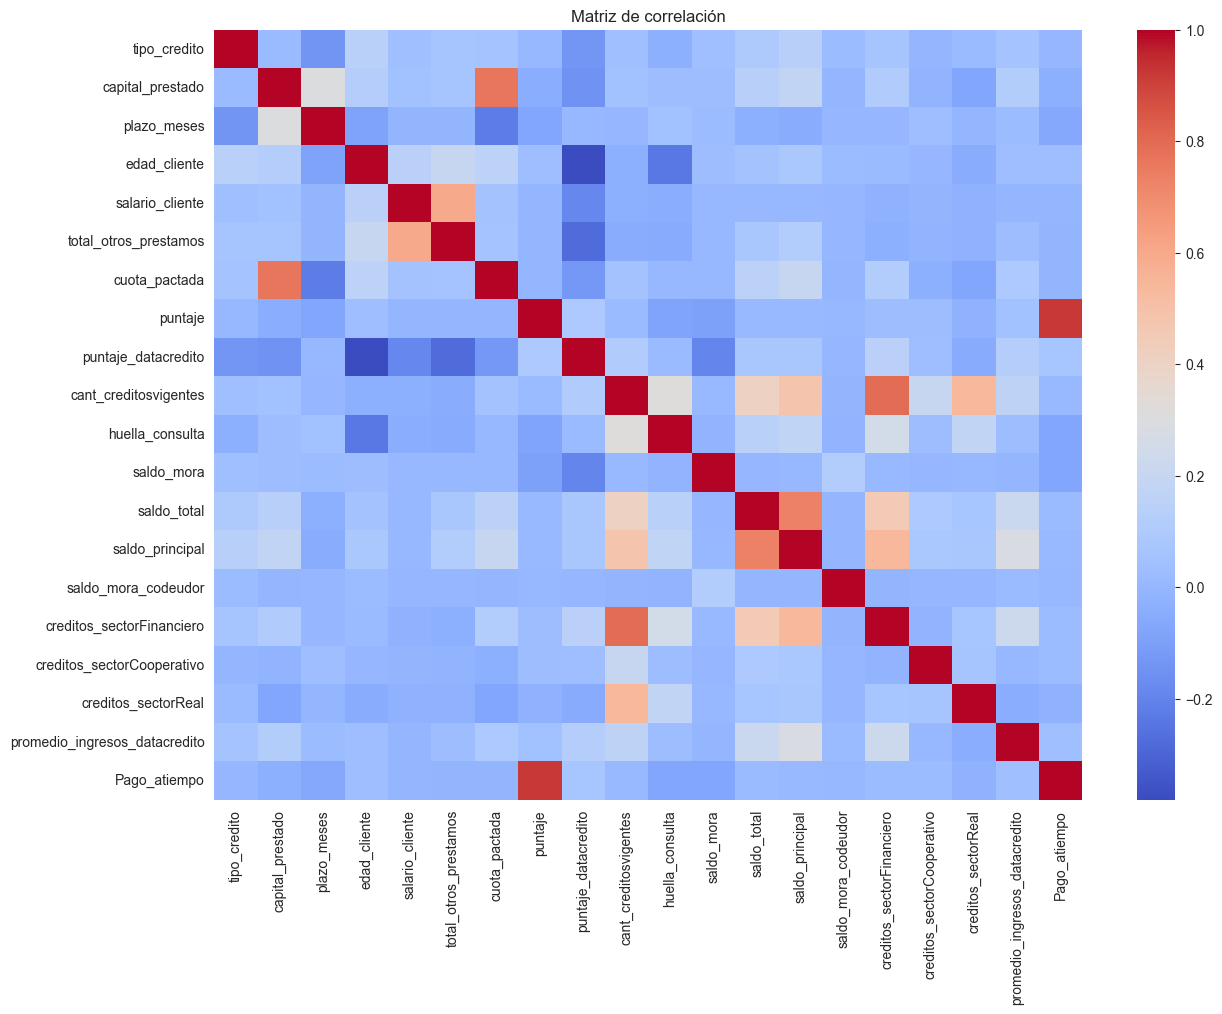

In [10]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de correlación")

plt.show()

## Interpretación

Se observan correlaciones moderadas entre algunas variables financieras y crediticias.

Las variables relacionadas con saldos, créditos vigentes y comportamiento crediticio presentan ciertas relaciones entre sí, lo cual resulta coherente desde el punto de vista del negocio.

No se observan correlaciones extremadamente altas que indiquen problemas severos de multicolinealidad.